In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

plt.style.use("seaborn-v0_8")

# Load dataset (file must be next to this notebook)
df = pd.read_csv("netflix_titles.csv")

print("Columns:\n", df.columns)
print("\nShape of dataset:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())


Columns:
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Shape of dataset: (8807, 12)

Missing values per column:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [2]:
# Filter only movies and clean duration
movies = df[df["type"] == "Movie"].copy()

# Drop rows with missing duration
movies = movies.dropna(subset=["duration"])

# Convert duration from "XXX min" to integer minutes
movies["duration_min"] = movies["duration"].str.replace(" min", "", regex=False).astype(int)

print("Movies sample:\n", movies[["title", "duration", "duration_min"]].head())
print("\nMovies shape:", movies.shape)

Movies sample:
                                title duration  duration_min
0               Dick Johnson Is Dead   90 min            90
6   My Little Pony: A New Generation   91 min            91
7                            Sankofa  125 min           125
9                       The Starling  104 min           104
12                      Je Suis Karl  127 min           127

Movies shape: (6128, 13)


In [18]:
from scipy.stats import shapiro

mean_duration = movies["duration_min"].mean()
percentage_less_60 = (movies["duration_min"] < 60).mean() * 100

print("Mean duration (minutes):", mean_duration)
print("Percentage of movies with duration < 60 minutes:", f"{percentage_less_60:.2f}%")

# Shapiro-Wilk test for normality (sample of 500)
stat, p = shapiro(movies["duration_min"].sample(500, random_state=1))
print("\nShapiro-Wilk statistic:", stat)
print("p-value:", p)

Mean duration (minutes): 99.57718668407311
Percentage of movies with duration < 60 minutes: 7.47%

Shapiro-Wilk statistic: 0.9781452277340709
p-value: 8.112505198062282e-07


In [4]:
mean = movies["duration_min"].mean()
std = movies["duration_min"].std()

within_std = ((movies["duration_min"] > mean - std) & 
              (movies["duration_min"] < mean + std)).mean() * 100

print("Percentage of movie durations within 1 std of mean:", f"{within_std:.2f}%")

Percentage of movie durations within 1 std of mean: 73.91%


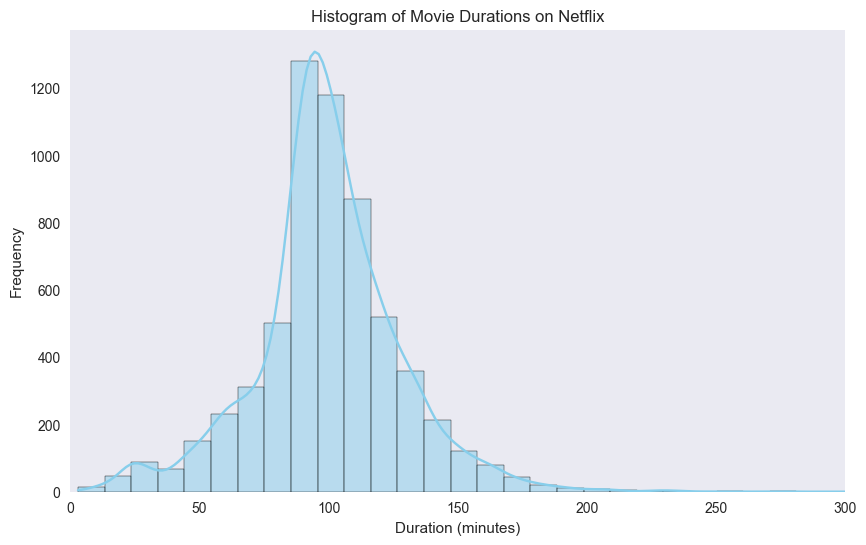

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(movies["duration_min"], bins=30, kde=True,
             color="skyblue", edgecolor="black")

plt.title("Histogram of Movie Durations on Netflix")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.grid()
plt.xlim(0, 300)

plt.show()

In [6]:
average_year = movies.groupby("release_year")["duration_min"].mean()
print("Average duration by year (last 6 years):\n", average_year.tail(6))

# Optional: export
# average_year.to_excel("average_duration_by_year.xlsx")

Average duration by year (last 6 years):
 release_year
2016    95.360182
2017    95.535248
2018    96.185137
2019    93.466035
2020    92.141199
2021    96.444043
Name: duration_min, dtype: float64


In [7]:
sample_movies = movies[["title", "release_year", "rating", "duration_min"]].head(10)
print("Sample of 10 movies:\n", sample_movies)

# Optional: export
# sample_movies.to_excel("sample10_movies.xlsx", index=False)

Sample of 10 movies:
                                                 title  release_year rating  \
0                                Dick Johnson Is Dead          2020  PG-13   
6                    My Little Pony: A New Generation          2021     PG   
7                                             Sankofa          1993  TV-MA   
9                                        The Starling          2021  PG-13   
12                                       Je Suis Karl          2021  TV-MA   
13                   Confessions of an Invisible Girl          2021  TV-PG   
16  Europe's Most Dangerous Man: Otto Skorzeny in ...          2020  TV-MA   
18                                          Intrusion          2021  TV-14   
22                                    Avvai Shanmughi          1996  TV-PG   
23       Go! Go! Cory Carson: Chrissy Takes the Wheel          2021   TV-Y   

    duration_min  
0             90  
6             91  
7            125  
9            104  
12           127  
13   

<Figure size 1200x600 with 0 Axes>

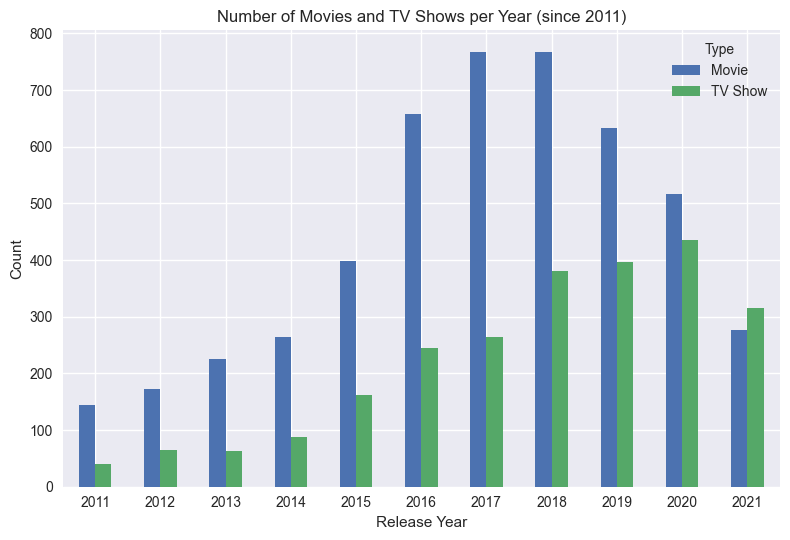

In [8]:
grouped_year_type = df.groupby(["release_year", "type"]).size().unstack(fill_value=0)

recent = grouped_year_type.loc[grouped_year_type.index > 2010]

plt.figure(figsize=(12, 6))
recent.plot(kind="bar", rot=0)
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.title("Number of Movies and TV Shows per Year (since 2011)")
plt.legend(title="Type")
plt.tight_layout()
plt.show()

Top 5 countries:
 country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Name: count, dtype: int64


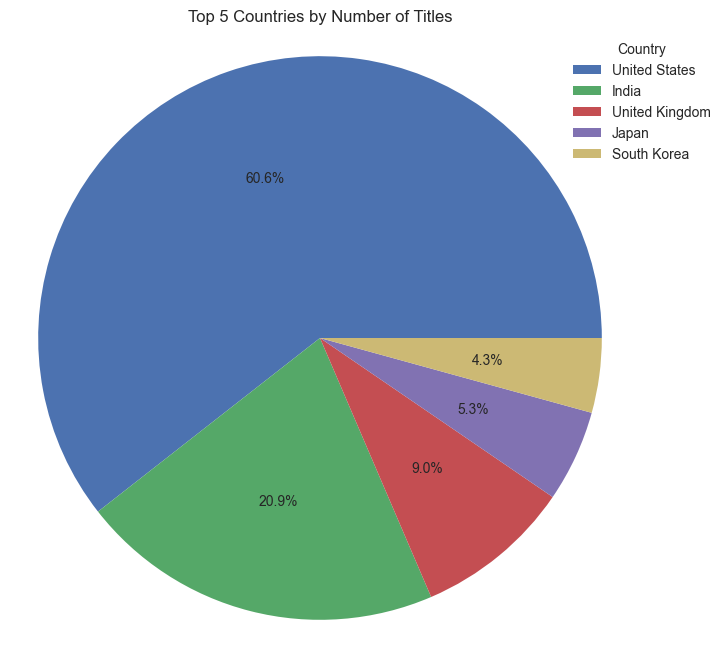

In [9]:
country_counts = df["country"].value_counts().head(5)
print("Top 5 countries:\n", country_counts)

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(country_counts, autopct="%1.1f%%")
plt.legend(wedges, country_counts.index, title="Country",
           loc="upper right", bbox_to_anchor=(1.15, 1))
plt.axis("equal")
plt.title("Top 5 Countries by Number of Titles")
plt.show()

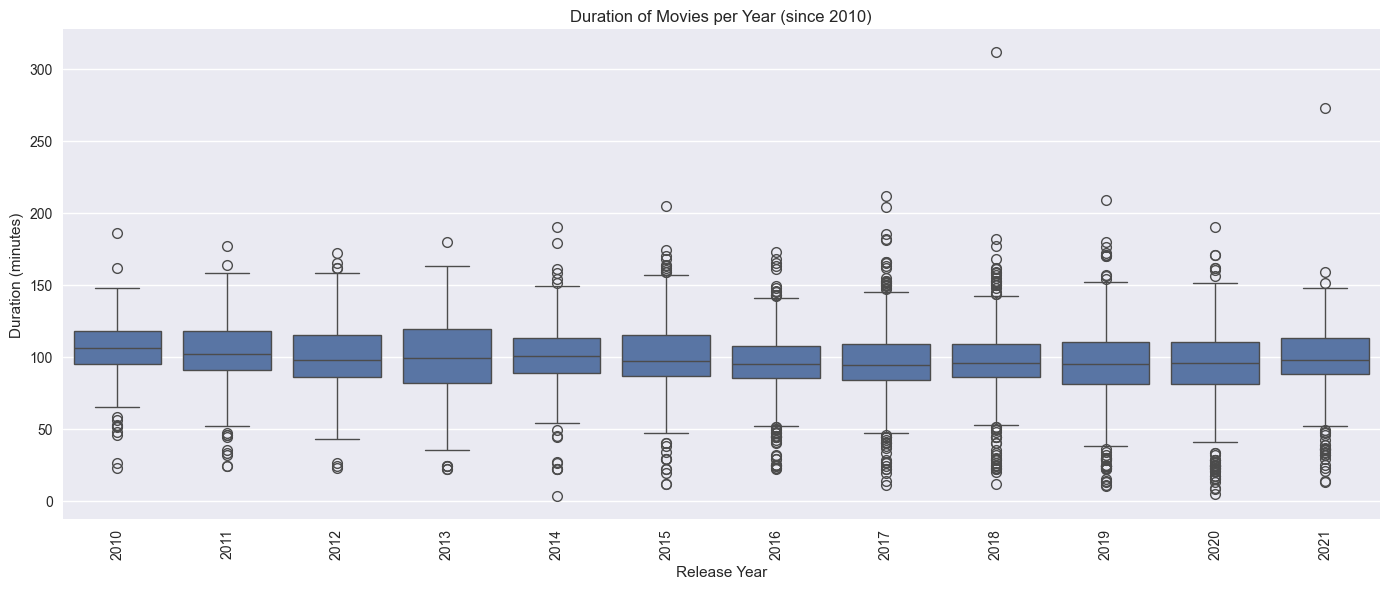

In [12]:
movies_recent = movies[movies["release_year"] > 2009]

plt.figure(figsize=(14, 6))
sns.boxplot(x="release_year", y="duration_min", data=movies_recent)
plt.xticks(rotation=90)
plt.xlabel("Release Year")
plt.ylabel("Duration (minutes)")
plt.title("Duration of Movies per Year (since 2010)")
plt.tight_layout()
plt.show()

Ratings pivot (top 10 rows):
 release_year  2015  2016  2017  2018  2019  2020  2021
rating                                                
G                0     3     1     2     1     1     0
NC-17            0     0     0     1     0     0     0
NR              17    20     2     1     0     0     0
PG              11    14    15    31    12    15    11
PG-13           25    34    32    30    19    21    14
R               66    85    73    52    39    48    21
TV-14           87   140   182   176   160    91    73
TV-G             6    13    20    18    15    26     9
TV-MA          135   273   337   358   286   220   110
TV-PG           35    52    80    71    62    46    20


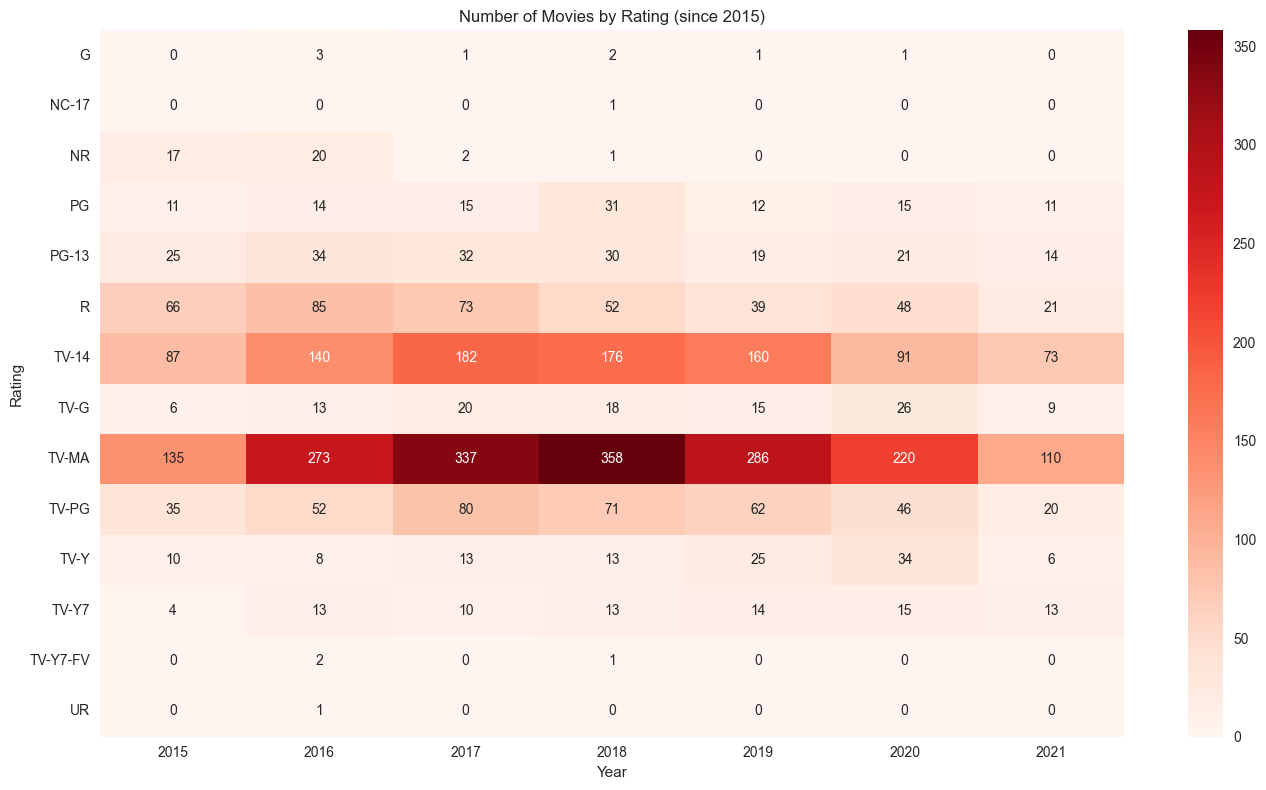

In [13]:
movies_ratings = df[df["type"] == "Movie"].copy()

# Drop missing release_year and rating
movies_ratings = movies_ratings.dropna(subset=["release_year", "rating"])

# Remove rows where rating contains "min" (to avoid duration-like strings)
movies_ratings = movies_ratings[~movies_ratings["rating"].str.contains("min", na=False)]

ratings = movies_ratings[movies_ratings["release_year"] > 2014] \
    .groupby(["release_year", "rating"]).size().reset_index(name="count")

ratings_pivot = ratings.pivot(index="rating", columns="release_year", values="count").fillna(0)
ratings_pivot = ratings_pivot.astype(int)

print("Ratings pivot (top 10 rows):\n", ratings_pivot.head(10))

plt.figure(figsize=(14, 8))
sns.heatmap(ratings_pivot, cmap="Reds", annot=True, fmt="g")
plt.title("Number of Movies by Rating (since 2015)")
plt.xlabel("Year")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

In [14]:
df_ml = df.copy()

# Keep relevant columns and drop missing values
df_ml = df_ml[["type", "duration", "rating", "listed_in"]]
df_ml = df_ml.dropna(subset=["duration", "rating", "listed_in"])

# Extract first genre from listed_in
df_ml["genre"] = df_ml["listed_in"].apply(lambda x: x.split(",")[0])

# Label Encoding
le_type = LabelEncoder()
le_rating = LabelEncoder()
le_genre = LabelEncoder()

df_ml["type_enc"] = le_type.fit_transform(df_ml["type"])
df_ml["rating_enc"] = le_rating.fit_transform(df_ml["rating"])
df_ml["genre_enc"] = le_genre.fit_transform(df_ml["genre"])

print(df_ml[["type", "rating", "genre", "type_enc", "rating_enc", "genre_enc"]].head())
print("\nType value counts:\n", df_ml["type"].value_counts())


      type rating                   genre  type_enc  rating_enc  genre_enc
0    Movie  PG-13           Documentaries         0           4         10
1  TV Show  TV-MA  International TV Shows         1           8         16
2  TV Show  TV-MA          Crime TV Shows         1           8          8
3  TV Show  TV-MA              Docuseries         1           8         11
4  TV Show  TV-MA  International TV Shows         1           8         16

Type value counts:
 type
Movie      6126
TV Show    2674
Name: count, dtype: int64


In [15]:
X = df_ml[["rating_enc", "genre_enc"]]
y = df_ml["type_enc"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(criterion="entropy", random_state=42)
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Decision Tree Train Accuracy:", f"{train_acc*100:.2f}%")
print("Decision Tree Test Accuracy:", f"{test_acc*100:.2f}%")

Decision Tree Train Accuracy: 100.00%
Decision Tree Test Accuracy: 99.89%


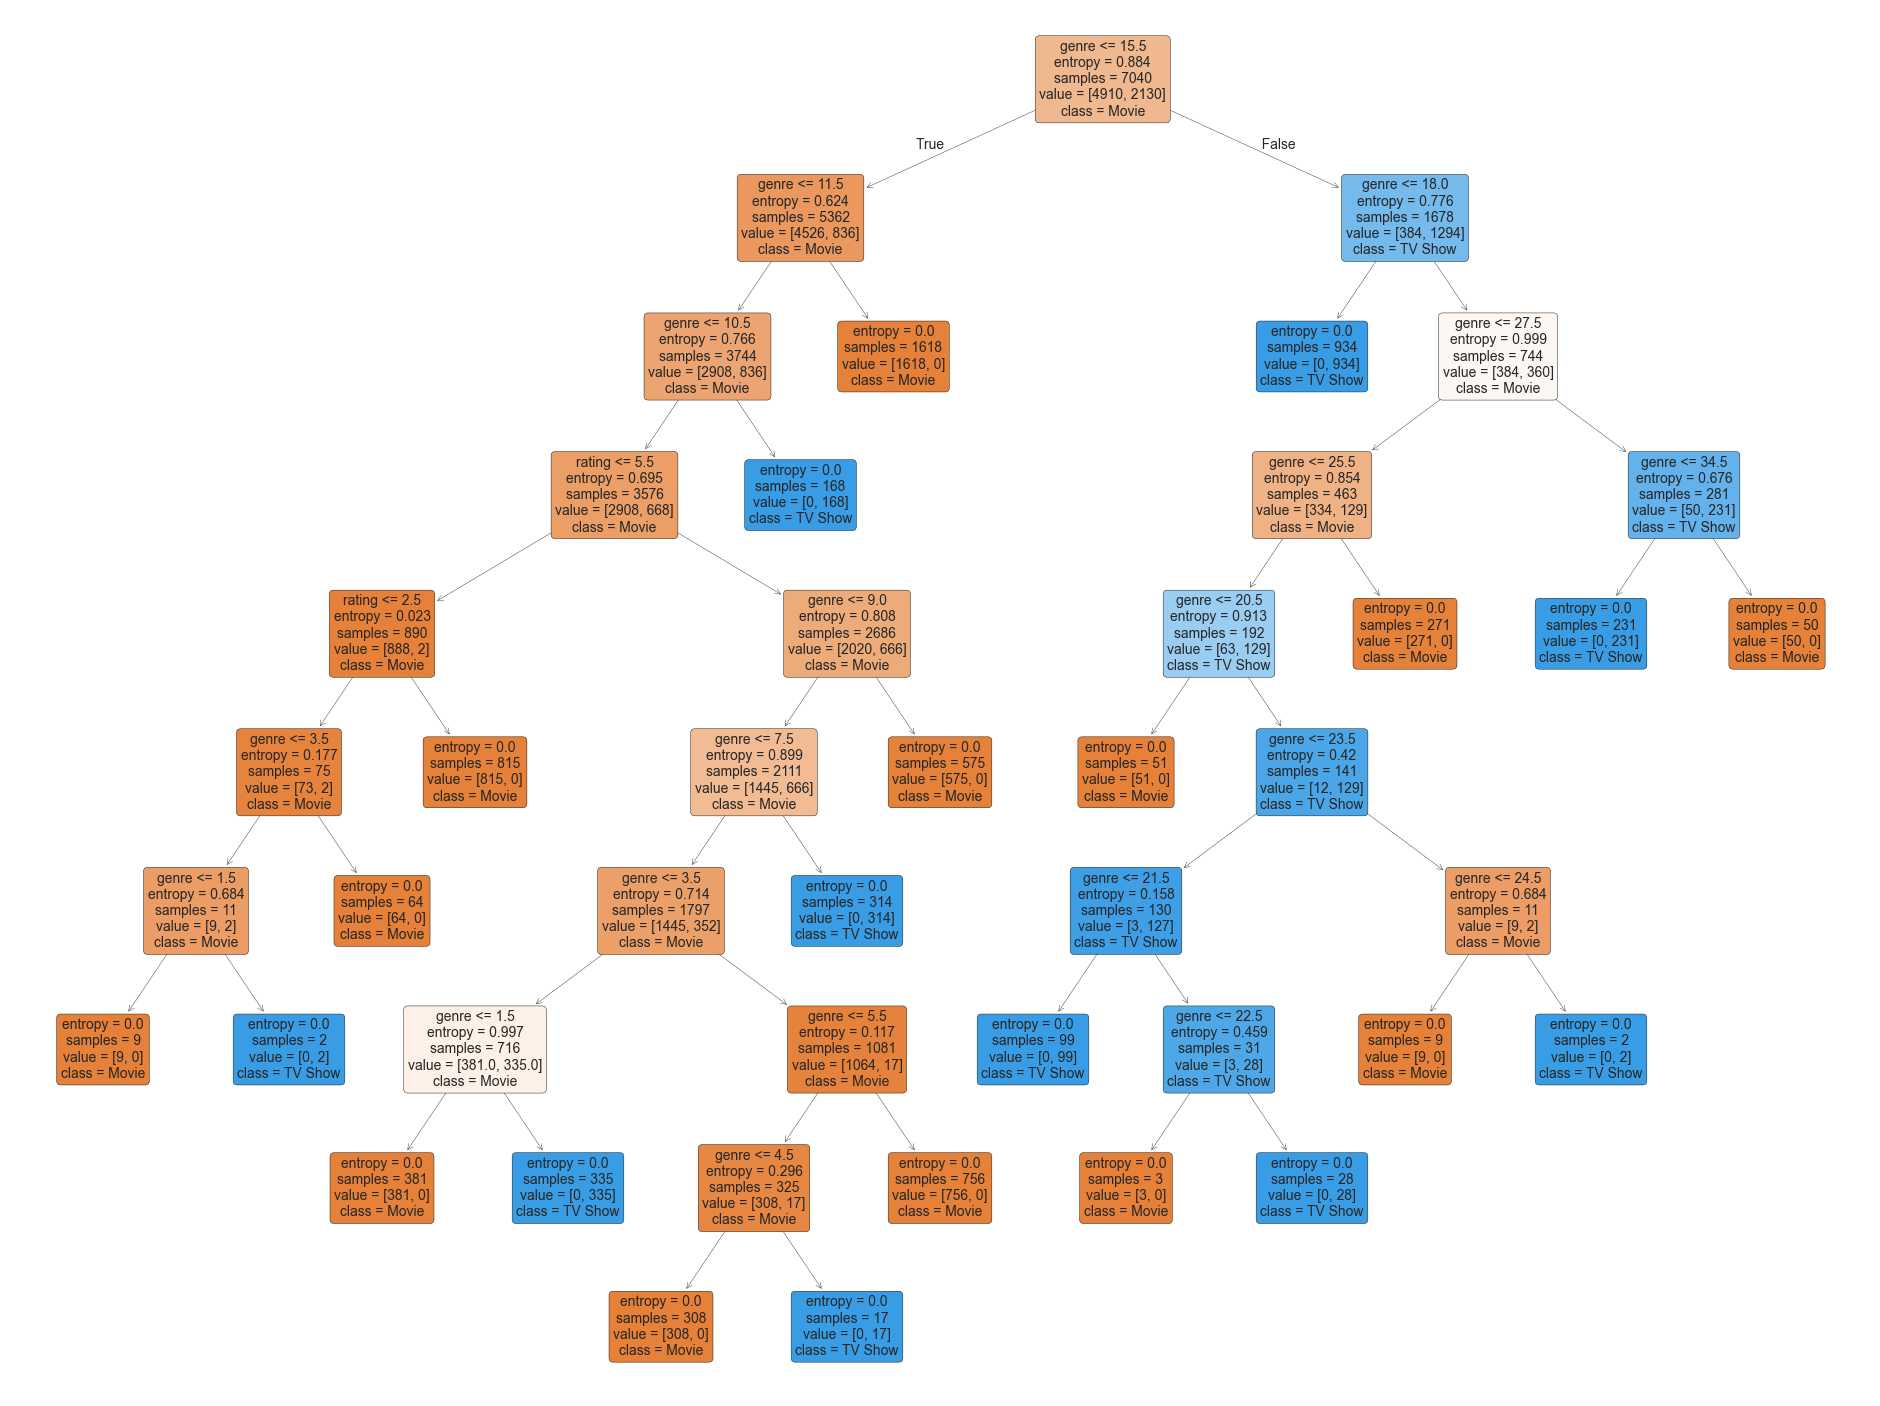

In [16]:
plt.figure(figsize=(24, 18))
tree.plot_tree(
    model,
    feature_names=["rating", "genre"],
    class_names=le_type.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()